For a tabular dataset of ~8,600 rows, **Machine Learning** (specifically XGBoost or Randomforest) is the superior choice as it outperforms Deep Learning on smaller, structured data.

Deep Learning typically requires much larger volumes of data to avoid **overfitting** and often lacks the interpretability needed to understand price drivers.

Focus my efforts on **feature engineering** and gradient boosting models, which will provide higher accuracy and faster training times for this specific scale.


RandomForestRegressor, xgboost, GradiantBoosting

In [37]:
%pip install category_encoders

In [38]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [39]:
df = pd.read_csv('nawy_properties_cleaned.csv', dtype={'id': str})
df.columns

Index(['id', 'location', 'property_name', 'property_type', 'description', 'm2',
       'Beds', 'Baths', 'payment_plan', 'price', 'url_path', 'tag',
       'cover_image', 'developer_logo', 'price_float', 'embedding_text'],
      dtype='object')

In [40]:
cols_to_drop = ['cover_image', 'developer_logo', 'embedding_text', 'url_path', 'price', 'description', 'payment_plan', 'property_name', 'tag', 'id']
df = df.drop(columns=cols_to_drop)
df = df.rename(columns={'price_float': 'price'})
df.head()

,location,property_type,m2,Beds,Baths,price
0,New Capital City,Apartment,101.0,2.0,1.0,4200000.0
1,6th settlement,Apartment,81.0,1.0,1.0,8786151.0
2,6th settlement,Apartment,73.0,1.0,1.0,8707294.0
3,El Sheikh Zayed,Apartment,122.0,1.0,2.0,16274000.0
4,6th of October City,Apartment,121.0,2.0,2.0,4588500.0


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8597 entries, 0 to 8596
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   location       8597 non-null   object 
 1   property_type  8597 non-null   object 
 2   m2             8585 non-null   float64
 3   Beds           7765 non-null   float64
 4   Baths          7843 non-null   float64
 5   price          8578 non-null   float64
dtypes: float64(4), object(2)
memory usage: 403.1+ KB


In [42]:
df.shape

(8597, 6)

## Dealing with nulls

In [43]:
df.isnull().sum()

,0
location,0
property_type,0
m2,12
Beds,832
Baths,754
price,19


In [44]:
df = df.dropna(subset=["price"])
df["m2"] = df["m2"].fillna(df["m2"].median())
df["Beds"] = df.groupby("property_type")["Beds"].transform(lambda x: x.fillna(x.median()))
df["Baths"] = df.groupby("property_type")["Baths"].transform(lambda x: x.fillna(x.median()))
df["Beds"] = df["Beds"].fillna(df["Beds"].median())
df["Baths"] = df["Baths"].fillna(df["Baths"].median())

In [45]:
df.isnull().sum()

,0
location,0
property_type,0
m2,0
Beds,0
Baths,0
price,0


In [46]:
counts = [df[col].value_counts().to_frame() for col in ['location', 'property_type']]
from IPython.display import display_html

def display_side_by_side(objs, titles):
    html_str = ''
    for obj, title in zip(objs, titles):
        html_str += f'<div style="float: left; margin-right: 20px;"><h3>{title}</h3>{obj.to_html()}</div>'
    display_html(html_str, raw=True)

display_side_by_side(counts, ['location', 'property_type'])

,count
location,
Ras El Hekma,1606
New Cairo,1353
New Capital City,657
Ain Sokhna,597
6th of October City,559
Mostakbal City,545
Sidi Abdel Rahman,476
El Sheikh Zayed,330
Sidi Heneish,269


In [47]:
# ── 2. Rare location grouping ────────────────────────────────────────────────
threshold = 20
rare = df['location'].value_counts()[lambda x: x < threshold].index
df['location'] = df['location'].replace(rare, 'Other')

In [48]:
# ── 3. Log-transform BEFORE computing luxury flag ────────────────────────────
df['price'] = np.log1p(df['price'])

# Fix: compute is_luxury on ORIGINAL m2 scale
df['is_luxury'] = (df['m2'] > 200).astype(int)   # ✅ before log

df['m2'] = np.log1p(df['m2'])

## Detecting Outliers

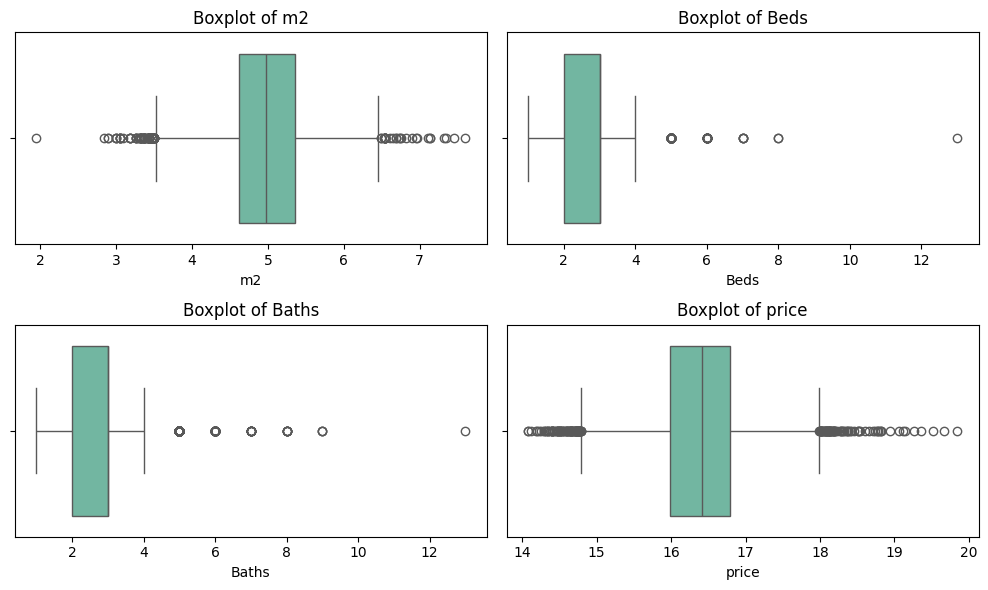

In [49]:
plt.figure(figsize=(10, 6))

# List of numerical columns to check for outliers
num_vars = ['m2', 'Beds', 'Baths', 'price']

for i, var in enumerate(num_vars, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[var], palette='Set2')
    plt.title(f'Boxplot of {var}', fontsize=12)
    plt.xlabel(var)

plt.tight_layout()
plt.show()

In [50]:
# Define numerical columns for outlier detection
num_vars = ['m2', 'Beds', 'Baths', 'price']

# Calculate outliers using IQR method
outlier_counts = {}

for var in num_vars:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count values outside the bounds
    outliers = df[(df[var] < lower_bound) | (df[var] > upper_bound)]
    outlier_counts[var] = len(outliers)

# Display the results
import pandas as pd
outlier_summary = pd.Series(outlier_counts).to_frame(name='Outlier Count')
print("Outlier Detection Summary (IQR Method):")
print(outlier_summary)

Outlier Detection Summary (IQR Method):
       Outlier Count
m2               105
Beds             123
Baths            331
price            177


These counts suggest that the 'Price' and 'Baths' columns have the most variance from the typical distribution, which is common in real estate datasets where luxury properties can skew the data.

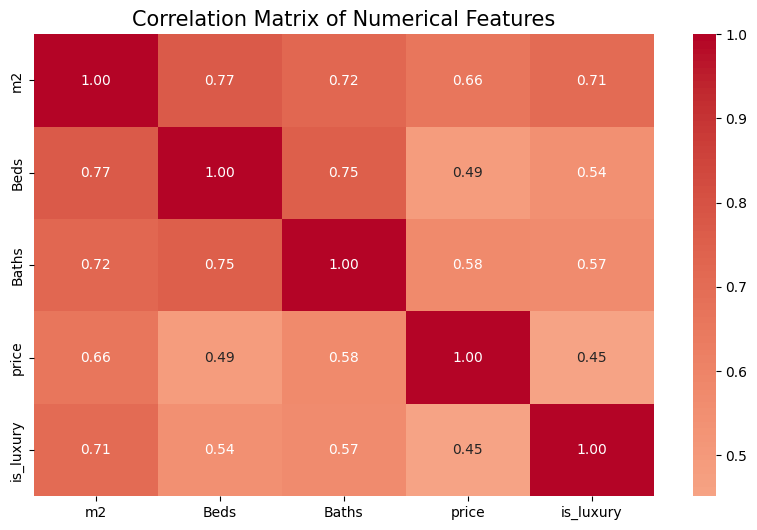

In [51]:
# Calculate the correlation matrix
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Visualize with a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features', fontsize=15)
plt.show()

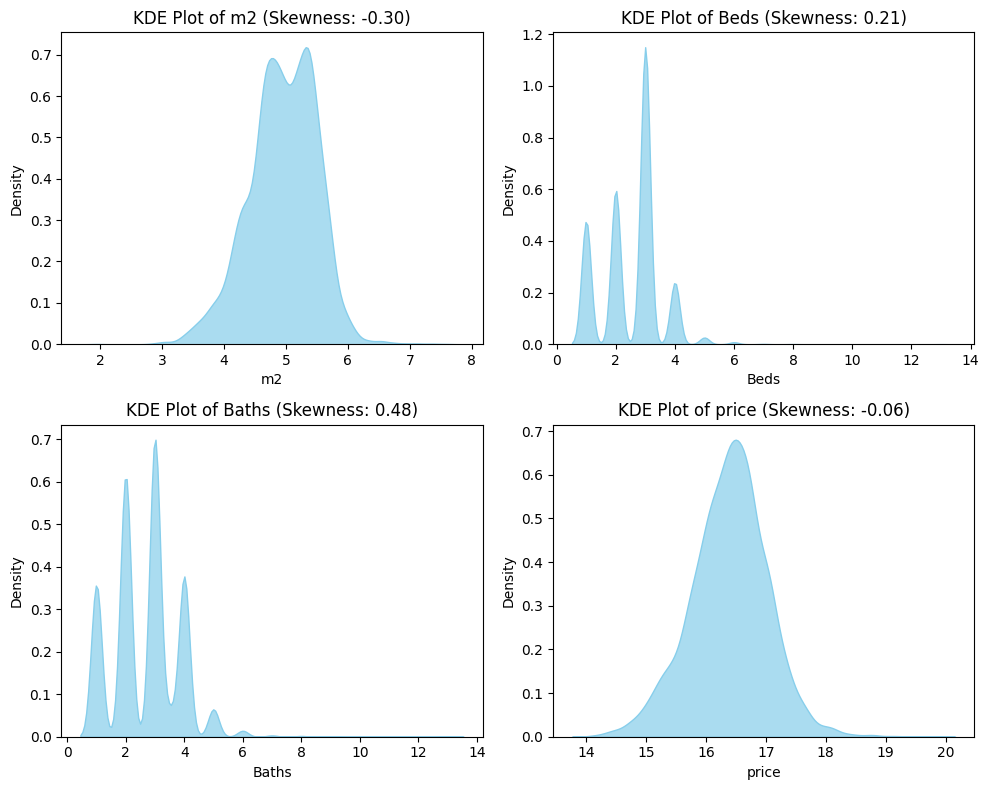

In [52]:
plt.figure(figsize=(10, 8))

# List of numerical columns to check for skewness
num_vars = ['m2', 'Beds', 'Baths', 'price']

for i, var in enumerate(num_vars, 1):
    plt.subplot(2, 2, i)
    sns.kdeplot(df[var], fill=True, color='skyblue', alpha=0.7)
    plt.title(f'KDE Plot of {var} (Skewness: {df[var].skew():.2f})', fontsize=12)
    plt.xlabel(var)
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

### **Transform Highly Skewed Features**
For price (Skewness: 8.67) and m2 (Skewness: 3.92), the data is too "bunched up" at the low end. Standard models struggle with this.
* Log Transformation: Apply $log(x + 1)$ to these columns. This pulls the extreme outliers closer to the mean and makes the distribution more "normal" (Gaussian).
* Why? It prevents the model from being overly biased by a $100M property that isn't representative of the general market.

In [53]:
# ── 4. One-hot encode property_type ─────────────────────────────────────────
df = pd.get_dummies(df, columns=["property_type"], drop_first=True)

In [54]:
# ── 5. Train/test split BEFORE any target-aware encoding ────────────────────
X = df.drop(columns=['price'])
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [55]:
# ── 6. Target encode location using ONLY train data ──────────────────────────
encoder = ce.TargetEncoder(cols=["location"])
X_train["location"] = encoder.fit_transform(X_train["location"], y_train)
X_test["location"]  = encoder.transform(X_test["location"])   # ✅ no leakage

In [56]:
# ── 7. Location stats using ONLY train data ──────────────────────────────────
loc_stats = X_train.groupby("location")["location"].agg(
    loc_price_mean=lambda x: y_train.loc[x.index].mean(),
    loc_price_std =lambda x: y_train.loc[x.index].std()
).reset_index()

# Merge back
X_train = X_train.merge(loc_stats, on="location", how="left")
X_test  = X_test.merge(loc_stats,  on="location", how="left")
X_test["loc_price_mean"] = X_test["loc_price_mean"].fillna(y_train.mean())
X_test["loc_price_std"]  = X_test["loc_price_std"].fillna(y_train.std())

In [57]:
# ── 8. Additional feature engineering ────────────────────────────────────────
for df_part in [X_train, X_test]:
    df_part["bed_bath_ratio"]  = df_part["Beds"] / (df_part["Baths"] + 1)
    df_part["total_rooms"]     = df_part["Beds"] + df_part["Baths"]
    df_part["m2_per_bed"]      = df_part["m2"] / (df_part["Beds"] + 1)

In [58]:
# ── 9. XGBoost with wider search ─────────────────────────────────────────────
xgb_model = xgb.XGBRegressor(
    random_state=42,
    objective='reg:squarederror',
    tree_method='hist',     # faster
    early_stopping_rounds=50
)

param_dist = {
    'n_estimators':      [800, 1200, 1500],
    'learning_rate':     [0.01, 0.03, 0.05],
    'max_depth':         [4, 5, 6, 7],
    'subsample':         [0.7, 0.8, 0.9],
    'colsample_bytree':  [0.6, 0.7, 0.8],
    'gamma':             [0, 0.05, 0.1],
    'min_child_weight':  [1, 3, 5],
    'reg_alpha':         [0, 0.1, 0.5],    # L1 regularization
    'reg_lambda':        [1, 2, 5],        # L2 regularization
}

search = RandomizedSearchCV(
    xgb_model, param_dist,
    n_iter=60, scoring='r2', cv=5,    # 5-fold is more reliable than 3
    n_jobs=-1, verbose=1, random_state=42
)

# Pass eval_set for early stopping
search.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

best = search.best_estimator_
y_pred = best.predict(X_test)

print(f"R²  : {r2_score(y_test, y_pred):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"Best params: {search.best_params_}")


Fitting 5 folds for each of 60 candidates, totalling 300 fits
R²  : 0.7054
MAE : 0.2586
Best params: {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 1200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.7}


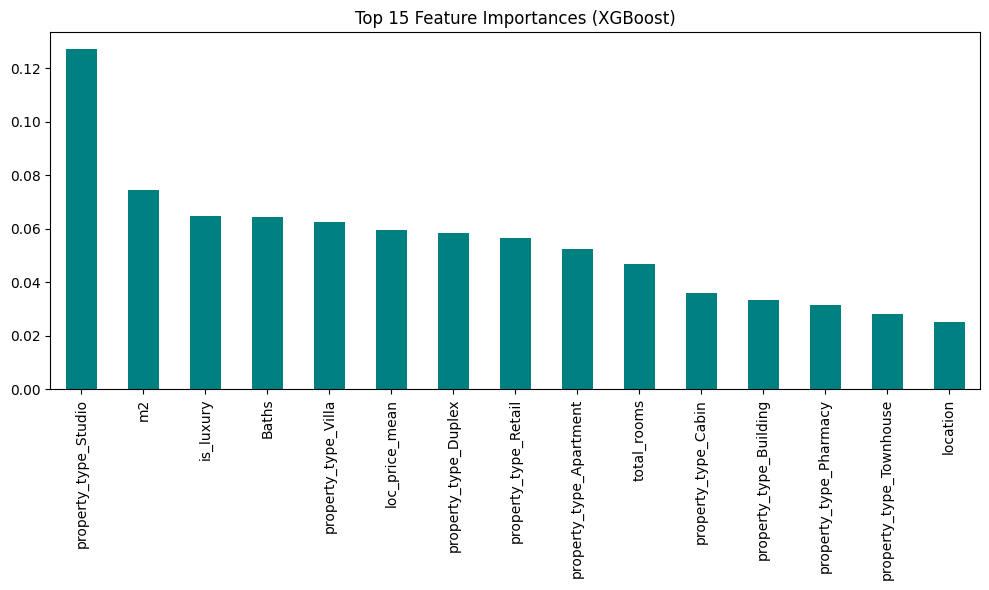

In [60]:
# ── 11. Feature importance ────────────────────────────────────────────────────
feat_imp = pd.Series(best.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind='bar', color='teal')
plt.title("Top 15 Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()

In [61]:
import joblib

# Save the best model
model_filename = 'best_xgb_model.joblib'
joblib.dump(best, model_filename)

# Also save the target encoder since it's needed for preprocessing raw data
encoder_filename = 'location_encoder.joblib'
joblib.dump(encoder, encoder_filename)

print(f"Successfully saved best model to: {model_filename}")
print(f"Successfully saved encoder to: {encoder_filename}")

Successfully saved best model to: best_xgb_model.joblib
Successfully saved encoder to: location_encoder.joblib


In [65]:
import joblib
import pandas as pd
import numpy as np

# 1. Load the model and encoder
loaded_model = joblib.load('best_xgb_model.joblib')
loaded_encoder = joblib.load('location_encoder.joblib')

# 2. Define a single raw input example
sample_data = {
    'location': 'New Capital City',
    'property_type': 'Apartment',
    'm2': 150.0,
    'Beds': 3.0,
    'Baths': 2.0
}
df_single = pd.DataFrame([sample_data])

# 3. Preprocessing
# a. Feature: is_luxury (on original scale)
df_single['is_luxury'] = (df_single['m2'] > 200).astype(int)

# b. Log transform m2
df_single['m2'] = np.log1p(df_single['m2'])

# c. Target encode location
df_single['location'] = loaded_encoder.transform(df_single[['location']])

# d. Add ratio features
df_single["bed_bath_ratio"] = df_single["Beds"] / (df_single["Baths"] + 1)
df_single["total_rooms"] = df_single["Beds"] + df_single["Baths"]
df_single["m2_per_bed"] = df_single["m2"] / (df_single["Beds"] + 1)

# e. Handle Location Stats (using main df as requested)
df_single['loc_price_mean'] = df_single['location']
# Calculate mean std from the main df grouping
df_single['loc_price_std'] = df.groupby('location')['price'].std().mean()

# f. One-hot encode property_type to match training columns exactly
# We use the feature names directly from the trained model to avoid missing columns
model_features = loaded_model.feature_names_in_

for col in model_features:
    if col.startswith('property_type_'):
        prop_name = col.replace('property_type_', '')
        df_single[col] = 1 if sample_data['property_type'] == prop_name else 0

# Ensure column order and presence matches the model's expected input features exactly
df_single = df_single[model_features]

# 4. Predict and Inverse Log
log_prediction = loaded_model.predict(df_single)[0]
final_price = np.expm1(log_prediction)

print(f"Predicted Price for {sample_data['property_type']} in {sample_data['location']}: {final_price:,.2f} EGP")

Predicted Price for Apartment in New Capital City: 8,276,329.50 EGP
